<a href="https://colab.research.google.com/github/JosefBirnoecker/Strukturbioinformatik_Projekt/blob/main/ex01_workbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 01 — Workbook: your own protein

This notebook is **deliberately almost empty.** Its companion, **`ex01_guide.ipynb`**,
walks the entire analysis through on one protein (1FSZ, FtsZ) with every cell filled in.
Here you rebuild that analysis on a protein of **your own** choosing.

**Read `ex01_guide.ipynb` first.** Then work here, with it open beside you.

## How to work in this notebook

- **Copy code across from the guide and adapt it.** `rcsb_chain`,
  `search_pdb`, `structure_table`, and the alignment helpers
  `hmmer_search`, `align`, `drop_redundant` and `conservation` are all written to be
  generic: they work on any protein, not just 1FSZ. Reusing them is the point.
- **Structure the notebook however you like.** The section headers below are a checklist
  of what has to be here, not a cell-by-cell template. Add cells, split them, reorder
  them, delete these prompts once you've answered them.
- **The reasoning is what's graded, not the code.** Every section below asks for a
  written conclusion as well as output. A notebook full of correct plots with no
  interpretation scores badly; one with an honest, well-argued interpretation of a
  messy result scores well.

## Using AI Tools

You may use AI assistants (ChatGPT, Claude, etc.) for syntax, debugging, and code
snippets. You must supply the biological reasoning, the justification for your choices,
and the critical evaluation of what came back. **"The AI said so" is not an answer.**

**Note:** two prompts below (B-factor flexibility, and conserved regions) are
predict-first: you write your prediction down *before* you run anything. That written
prediction is the graded artefact. Being wrong costs you nothing; not having made a
prediction costs you the marks.

## Setup

Copy the guide's two setup cells here, the install cell and the imports cell, and run
them first. A Colab notebook starts empty, so nothing from the guide's session carries over.

In [1]:
# Check if running on Google Colab
try:
    from google.colab import drive  # noqa: F401  (import is the availability test)
    is_google_colab = True
except ImportError:
    is_google_colab = False

# If on Google Colab, install the package
if is_google_colab:
    %pip install numpy==2.1.3 scipy==1.16.3 pandas==2.2.3 biopandas==0.4.1 py3dmol==2.4.0 biopython==1.85 pyfamsa==0.7.0 pymsaviz==0.5.0

# NOTE: Ignore specific warning message from ipykernel=5.5.6
import warnings
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.0/879.0 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 7.4 MB/s eta 0:00:00


In [2]:
import gzip
import io
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from biopandas.pdb import PandasPdb
from Bio import SeqIO
from Bio.Align import MultipleSeqAlignment
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from pyfamsa import Aligner, Sequence
from pymsaviz import MsaViz
import py3Dmol


# Suppress all warnings at the Python level
warnings.filterwarnings('ignore')

# Also set environment variable to suppress warnings
os.environ['PYTHONWARNINGS'] = 'ignore'

# pandas draws through matplotlib by default -- df.plot() gives us a real Axes back,
# which keeps most plots in this notebook to two or three lines.
print("All libraries loaded successfully")

All libraries loaded successfully


---

## Character Sheet — your capstone protein

You **choose** your protein from the candidate list in `candidate_proteins.ipynb`, linked
from the README. **The ligand is not a choice**: each candidate is listed with the one
ligand that has already been run end to end with that protein, through molecular dynamics,
docking and a simulation of the two together. Pick a different het group out of the same
crystal and the later exercises will fail, or run and give you a meaningless number.

That pairing is the spine of the course: the same protein and ligand run through ex02
(AlphaFold), ex03 (molecular dynamics), ex04 (docking), and your final project. Choose one
you will be happy to live with for four days.

Record your choice:

- **PDB ID:** 2IYS
- **Protein name:** Shikimate kinase
- **Organism:** Mycobacterium tuberculosis H37Rv
- **Method and resolution** (X-ray? NMR? cryo-EM? at what resolution?): X-ray Diffraction (resolution: 1.40 Å)
- **Ligand (CCD code and name):** SKM - (3R,4S,5R)-3,4,5-TRIHYDROXYCYCLOHEX-1-ENE-1-CARBOXYLIC ACID


### Now catalogue *everything* in the structure

The candidate list names **one** ligand for your protein. Your structure almost certainly contains **more than
one** non-protein species, and telling them apart is the point of this section.

List **every** heteroatom species in your entry — the way the guide does for 1FSZ — with
how many atoms and how many copies of each. Then classify each one:

**Notes on how to do this by students:**
1. go to rcsb.org and search for protein (4 digit code)
2. go to "small molecules" section (table of ligands)
3. name is given, chain column tells number of copies ("A" meaning one copy in chain A)
4. count number of heavy atoms in in formula (SKM --> $C_7 H_{10} O_5$ --> 12 atoms)
5. biological vs. experimental artifact comes from context: while according to the paper SKM is a substrate and therefore biological, when looking at the crystalization conditions in the "Experiment" tab, we can identify Triple-HCL and therefore conclude that the Cl most likely would be an experimental artifact

| Code | Name | Atoms | Copies | Biological, or experimental artifact? | Evidence |
|---|---|---|---|---|---|
|SKM |(3R,4S,5R)-3,4,5-TRIHYDROXYCYCLOHEX-1-ENE-1-CARBOXYLIC ACID |12 |1 |biological |paper is about interaction between shikimate kinase (enzyme) <br> and shikimate (substrate), therefore indicating biological connection|
|CL |Chloride Ion |1 |1 |experimental artifact|Crystalization conditions in experiment tab on pdb state use of Triple-HCL,<br> leading to the assumption of CL beeing an experimental artifact|

**"Evidence" is the graded column.** For each species, say *how you decided*, using more
than one line of reasoning:

- What does the **RCSB entry page or the paper** say the structure was solved to study?
- **Where does it sit** — buried in a pocket making several contacts, or perched in a
  surface groove?
- Do you **recognise it as a lab reagent**? (glycerol, ethylene glycol, HEPES, MES, PEG,
  sulfate, acetate, DMSO…)
- Does it **recur in related structures** of the same protein, or appear only here?
- What do its **occupancy and B-factors** suggest about how well-ordered it is?

**Then find the binding site of your chosen ligand.**

**Look first.** `show_structure(your_pdb, ligand="XXX", pocket_of="XXX")` asks the viewer
itself for the residues within 4 Å of that species and labels them, using the same `within`
and `byres` selection PyMOL uses. Read them off the picture: how many are there, and what
kind are they? Polar, charged, hydrophobic, a recognisable motif?

> **What the pocket looks like:**

**Then type them out**, the way the guide does, as a plain list of residue names. A
binding site is short enough to type, and typing it is what makes you look at each residue
instead of at a number. Keep the list: ex03 and ex04 both build on it.

> **My ligand's contact residues:**

**If your structure is NMR**, there may be no heteroatoms at all, and there will be no
B-factors or occupancies — several rows of the table above will not apply. Say so
explicitly and explain what you can and cannot determine from an NMR ensemble. That is a
real, informative answer, not a failure to complete the task.

**If a species surprises you** — something you cannot classify either way — say so. "I
could not determine whether X is biological, and here is what I checked" is worth more
than a confident guess.

---

## 1. Your protein, and every structure of its family

Start from the chain that binds your ligand (`rcsb_chain` gives its UniProt sequence),
list its family's structures (`search_pdb`, `structure_table`) and draw the guide's two
plots.

**Report:** how many structures, solved how? Where does *yours* sit: method, resolution
against the rest, R-free? You keep your structure: the point is knowing its strengths and
weaknesses.

In [3]:
CHAIN_QUERY = """query($entry: String!, $chain: String!) {
  polymer_entity_instance(entry_id: $entry, asym_id: $chain) {
    rcsb_polymer_entity_instance_container_identifiers { auth_to_entity_poly_seq_mapping }
    rcsb_polymer_instance_feature { type name provenance_source
                                    feature_positions { beg_seq_id end_seq_id } }
    polymer_entity {
      rcsb_polymer_entity_feature { type name provenance_source
                                    feature_positions { beg_seq_id end_seq_id } }
      rcsb_polymer_entity_align { reference_database_name reference_database_accession
        aligned_regions { entity_beg_seq_id ref_beg_seq_id length } }
      uniprots { rcsb_id rcsb_uniprot_protein { sequence }
                 rcsb_uniprot_feature { type name feature_positions { beg_seq_id end_seq_id } } }
} } }"""

# The annotation types kept, and what each one is. RCSB serves many more (validation
# scores per residue, hydropathy, disorder predictions); these are the ones drawn here.
KINDS = {"CATH": "domain", "SCOP": "domain", "ECOD": "domain", "Pfam": "domain",
         "HELIX_P": "helix", "SHEET": "strand",
         "BINDING_SITE": "binding site", "ACTIVE_SITE": "active site"}


def rcsb_chain(pdb_id: str, chain: str = "A") -> tuple[str, str, pd.Series, pd.DataFrame]:
    """Everything RCSB knows about one chain, from one GraphQL request.

    Returns the UniProt accession, the UniProt sequence, `to_structure` (a Series from
    UniProt position to the residue number the file uses: the two often differ, through a
    tag, a construct that starts mid-protein or the authors' own scheme), and a table of
    annotations, one row per annotated residue: its source (CATH, SCOPe, ECOD, Pfam,
    PROMOTIF for secondary structure, PDB, UniProt), its kind (domain, helix, strand,
    binding site, active site), its name, and the residue in the file's numbering.
    `chain` is the chain ID as the file writes it.
    """
    answer = requests.post("https://data.rcsb.org/graphql", json={
        "query": CHAIN_QUERY, "variables": {"entry": pdb_id, "chain": chain}})
    found = answer.json()["data"]["polymer_entity_instance"]
    entity = found["polymer_entity"]
    # The file's residue number for each position of the chain's sequence (1, 2, 3, ...)
    author = found["rcsb_polymer_entity_instance_container_identifiers"][
        "auth_to_entity_poly_seq_mapping"]
    in_file = pd.Series([int(n) for n in author], index=range(1, len(author) + 1))

    uniprot = next(a for a in entity["rcsb_polymer_entity_align"]
                   if a["reference_database_name"] == "UniProt")
    accession = uniprot["reference_database_accession"]
    to_structure = pd.Series({
        region["ref_beg_seq_id"] + k: in_file[region["entity_beg_seq_id"] + k]
        for region in uniprot["aligned_regions"] for k in range(region["length"])})
    record = next(u for u in entity["uniprots"] if u["rcsb_id"] == accession)

    # Chain and entity annotations count in sequence positions, UniProt's in UniProt
    # positions: each is turned into the file's numbering with its own map.
    annotated = [(f, in_file) for f in (found["rcsb_polymer_instance_feature"] or [])
                 + (entity["rcsb_polymer_entity_feature"] or [])]
    annotated += [(f, to_structure) for f in record["rcsb_uniprot_feature"] or []]
    rows = []
    for feature, numbering in annotated:
        if feature["type"] not in KINDS:
            continue
        residues = [int(numbering[position])
                    for span in feature["feature_positions"] or []
                    for position in range(span["beg_seq_id"],
                                          (span["end_seq_id"] or span["beg_seq_id"]) + 1)
                    if position in numbering.index]  # a single residue has no end
        name = feature["name"] or ""
        if KINDS[feature["type"]] == "domain" and residues:  # two domains can share a name
            name = f"{name} ({min(residues)}-{max(residues)})"
        rows += [{"source": feature.get("provenance_source") or "UniProt",
                  "kind": KINDS[feature["type"]], "name": name, "residue": residue}
                 for residue in residues]
    return accession, record["rcsb_uniprot_protein"]["sequence"], to_structure, pd.DataFrame(rows)


def search_pdb(sequence: str, identity_cutoff: float = 0.3) -> list[str]:
    """Every PDB entry whose sequence matches `sequence`, best match first."""
    query = {"type": "terminal", "service": "sequence",
             "parameters": {"evalue_cutoff": 1, "identity_cutoff": identity_cutoff,
                            "target": "pdb_protein_sequence", "value": sequence}}
    response = requests.post(
        "https://search.rcsb.org/rcsbsearch/v2/query",
        json={"query": query, "return_type": "entry",
              "request_options": {"return_all_hits": True,
                                  "sort": [{"sort_by": "score", "direction": "desc"}]}},
    )
    response.raise_for_status()
    return [hit["identifier"] for hit in response.json().get("result_set", [])]


def structure_table(pdb_ids: list[str]) -> pd.DataFrame:
    """Method, resolution, R-free and deposition year for each entry, one row per entry.

    RCSB's Data API speaks GraphQL: one query names the fields wanted, and answers for
    hundreds of entries at once instead of one request each. Not every method reports
    every number: NMR has no resolution, cryo-EM no R-free, and an integrative model (built
    from several kinds of data) neither, so those come back empty.
    """
    query = """query($ids: [String!]!) { entries(entry_ids: $ids) {
      rcsb_id rcsb_entry_info { experimental_method resolution_combined }
      refine { ls_R_factor_R_free } rcsb_accession_info { deposit_date } } }"""
    entries = []
    for start in range(0, len(pdb_ids), 500):  # a few hundred per request keeps it quick
        answer = requests.post("https://data.rcsb.org/graphql", json={
            "query": query, "variables": {"ids": pdb_ids[start:start + 500]}})
        entries += answer.json()["data"]["entries"]
    return pd.DataFrame([{
        "pdb_id": e["rcsb_id"],
        "method": e["rcsb_entry_info"]["experimental_method"],
        "resolution": (e["rcsb_entry_info"]["resolution_combined"] or [None])[0],
        "r_free": (e["refine"] or [{}])[0].get("ls_R_factor_R_free"),
        "year": int(e["rcsb_accession_info"]["deposit_date"][:4]),
    } for e in entries])

In [4]:
accession, query, to_structure, features = rcsb_chain("2IYS", "A")
pdb_ids = search_pdb(query)
family = structure_table(pdb_ids)

print(f"2IYS chain A is UniProt {accession}, {len(query)} residues")
print(f"Structures of the family in the PDB: {len(family)}")
family.head()

2IYS chain A is UniProt P9WPY3, 176 residues
Structures of the family in the PDB: 43


,pdb_id,method,resolution,r_free,year
0,1L4U,X-ray,1.80,0.24900,2002
1,1WE2,X-ray,2.30,0.28700,2004
2,1ZYU,X-ray,2.90,0.25100,2005
3,2DFN,X-ray,1.93,0.26687,2006
4,2DFT,X-ray,2.80,0.28162,2006


## Where 2IYS sits among them

In [5]:
print(family["method"].value_counts().to_string(), "\n")

mine = family.set_index("pdb_id").loc["2IYS"]
xray = family.loc[family["method"] == "X-ray", "resolution"].dropna()
print(f"2IYS: {mine['method']}, {mine['resolution']:.2f} Å, R-free {mine['r_free']:.3f}, "
      f"deposited {mine['year']}")
print(f"{(xray < mine['resolution']).sum()} of the family's {len(xray)} X-ray structures "
      f"are sharper; their median is {xray.median():.2f} Å")

method
X-ray    40
EM        3 

2IYS: X-ray, 1.40 Å, R-free 0.212, deposited 2006
1 of the family's 40 X-ray structures are sharper; their median is 1.99 Å


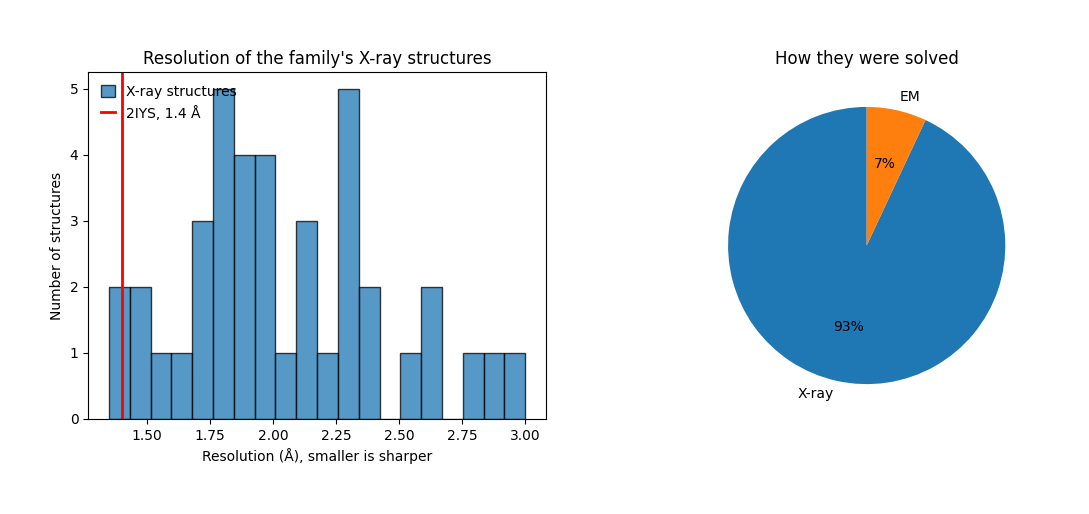

In [6]:
fig, (hist, pie) = plt.subplots(1, 2, figsize=(13, 4.5))

xray.plot.hist(ax=hist, bins=20, edgecolor="black", alpha=0.75, label="X-ray structures",
               title="Resolution of the family's X-ray structures")
hist.axvline(mine["resolution"], color="red", lw=2, label=f"2IYS, {mine['resolution']:.1f} Å")
hist.set(xlabel="Resolution (Å), smaller is sharper", ylabel="Number of structures")
hist.legend()

family["method"].value_counts().plot.pie(ax=pie, autopct="%1.0f%%", startangle=90,
                                          title="How they were solved")
pie.set_ylabel("")
plt.show()

---

## 2. Visualization

Produce, with a sentence on what each one shows you:

- Your structure coloured by its annotations (from `rcsb_chain`): secondary
  structure, domains, and binding or active sites. Say whose each is (CATH, UniProt, ...);
  one domain is an answer too
- If your structure has a ligand: zoom in on it and its contacts, as the guide's GDP
  view does

You will come back to this section: once you have the alignment from section 4, you add a
**conserved-residue view** to this set.

In [7]:
def load_structure(pdb_id: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Protein atoms and heteroatoms for one entry, as two DataFrames."""
    ppdb = PandasPdb().fetch_pdb(pdb_id)
    return ppdb.df["ATOM"], ppdb.df["HETATM"]


def heteroatom_inventory(hetatms: pd.DataFrame) -> pd.DataFrame:
    """Every non-protein species in the file, with how many atoms and copies each has."""
    return (
        hetatms.groupby("residue_name")
        .agg(atoms=("atom_number", "size"), copies=("residue_number", "nunique"))
        .sort_values("atoms", ascending=False)
    )


def bfactor_profile(atoms: pd.DataFrame) -> pd.Series:
    """CA B-factors indexed by residue number.

    NaN wherever the crystal resolved nothing. Reindexing onto the full range is what
    makes matplotlib draw real gaps instead of joining a line straight across them.
    """
    ca = atoms[atoms["atom_name"] == "CA"]
    profile = (ca.set_index("residue_number")["b_factor"]
               .reindex(range(ca["residue_number"].min(), ca["residue_number"].max() + 1)))
    profile.index.name = "Residue number"
    return profile


def show_structure(pdb_id: str, color: str = "spectrum",
                   groups: dict[str, list[int]] | None = None,
                   highlight: list[int] | tuple[int, ...] = (),
                   ligand: str | None = None, pocket_of: str | None = None,
                   label_pocket: bool = True, radius: float = 4.0,
                   width: int = 800, height: int = 500) -> py3Dmol.view:
    """Cartoon view of an entry.

    `color` is "spectrum" (along the chain, N-terminus blue to C-terminus red) or
    "b-factor" (rigid blue to flexible red). `groups` names sets of residues, each drawn in
    its own colour on grey, with the key printed. `highlight` colours those residues red;
    `ligand` shows a heteroatom as sticks; `pocket_of` asks the viewer itself for the
    residues lining that heteroatom, with `within` and `byres`, the same two words PyMOL
    uses. `hetflag` keeps the ligand and the waters out of the answer.
    """
    view = py3Dmol.view(query=f"pdb:{pdb_id}", width=width, height=height)
    if color == "b-factor":
        # Colour between the 5th and 95th percentile, so a few extreme atoms do not
        # wash everything else out. The range runs high to low: 3Dmol's red-white-blue
        # gradient starts red at its first value.
        atoms, _ = load_structure(pdb_id)
        low, high = atoms["b_factor"].quantile([0.05, 0.95])
        view.setStyle({"cartoon": {"colorscheme": {
            "prop": "b", "gradient": "rwb", "min": high, "max": low}}})
    elif groups or len(highlight) or pocket_of:
        view.setStyle({"cartoon": {"color": "lightgrey"}})
    else:
        view.setStyle({"cartoon": {"color": "spectrum"}})
    palette = ["crimson", "gold", "royalblue", "seagreen", "darkorange", "purple"]
    for (name, residues), colour in zip((groups or {}).items(), palette):
        view.addStyle({"resi": list(residues)}, {"cartoon": {"color": colour}})
        print(f"{colour:>11}: {name} ({len(residues)} residues)")
    if len(highlight):
        view.addStyle({"resi": list(highlight)}, {"cartoon": {"color": "red"}})
        view.addStyle({"resi": list(highlight)}, {"stick": {"color": "red"}})
    if pocket_of:
        pocket = {"hetflag": False, "byres": True,
                  "within": {"distance": radius, "sel": {"resn": pocket_of}}}
        view.addStyle(pocket, {"stick": {"colorscheme": "redCarbon"}})
        if label_pocket:
            view.addResLabels(pocket, {"font": "Arial", "fontSize": 10,
                                       "fontColor": "black", "showBackground": False})
    if ligand:
        view.addStyle({"resn": ligand}, {"stick": {"colorscheme": "greenCarbon"}})
    if pocket_of:
        view.zoomTo({"resn": pocket_of})
    else:
        view.zoomTo()
    return view

In [8]:
# The structure we are studying, coloured from N-terminus (blue) to C-terminus (red).
show_structure("2IYS").show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### What is known about this chain, drawn on 2IYS

`rcsb_chain` already retrieved the available annotations for chain A of 2IYS (Shikimate kinase from *Mycobacterium tuberculosis*), including their sources. These include protein domains classified by CATH, SCOPe, ECOD and Pfam, secondary structure elements such as helices and β-strands assigned by PROMOTIF, and functional sites annotated by the PDB and UniProt. The annotations are mapped to the residue numbering of 2IYS, allowing them to be visualized directly on our crystal structure.


In [9]:
features.groupby(["kind", "source", "name"])["residue"].agg(["count", "min", "max"])

count  \
kind         source   name                                                        
binding site PDB      ligand CL                                               1   
                      ligand SKM                                              8   
             UniProt                                                         13   
domain       CATH     P-loop containing nucleotide triphosphate hydro...    175   
             ECOD     Ras (2-166)                                           165   
             Pfam     Shikimate kinase (SKI) (11-167)                       157   
             SCOPe    automated matches (1-184)                             184   
helix        PROMOTIF helix                                                 115   
strand       PROMOTIF sheet                                                  19   

                                                                          min  \
kind         source   name                                                      
binding site PDB      ligand CL                                            21   
                      ligand SKM                                           34   
             UniProt                                                       12   
domain       CATH     P-loop containing nucleotide triphosphate hydro...    2   
             ECOD     Ras (2-166)                                           2   
             Pfam     Shikimate kinase (SKI) (11-167)                      11   
             SCOPe    automated matches (1-184)                             1   
helix        PROMOTIF helix                                                14   
strand       PROMOTIF sheet                                                 5   

                                                                          max  
kind         source   name                                                     
binding site PDB      ligand CL                                            21  
                      ligand SKM                                          136  
             UniProt                                                      153  
domain       CATH     P-loop containing nucleotide triphosphate hydro...  176  
             ECOD     Ras (2-166)                                         166  
             Pfam     Shikimate kinase (SKI) (11-167)                     167  
             SCOPe    automated matches (1-184)                           184  
helix        PROMOTIF helix                                               164  
strand       PROMOTIF sheet                                               149

### Structural annotations of 2IYS

The annotation table shows that chain A of 2IYS contains a shikimate kinase domain, classified by Pfam across residues 11–167. CATH and ECOD assign the protein to broader structural classifications. PROMOTIF identifies 115 residues in α-helices and 19 residues in β-strands.

The PDB annotations identify eight residues associated with the SKM binding site and one with the chloride ion (CL). UniProt provides additional binding-site annotations.

These annotations provide a basis for visualizing the protein's secondary structure, domain organization, and ligand-binding regions.

**Secondary structure of 2IYS**, as assigned by PROMOTIF from the experimental crystal structure. α-Helices and β-strands are highlighted in different colors, while the remaining regions are shown in grey.

In [10]:
shown = features[features["source"] == "PROMOTIF"]
kind = shown.groupby("kind")["residue"].apply(list)
show_structure("2IYS", groups={"helix": kind["helix"], "strand": kind["strand"]}).show()

    crimson: helix (115 residues)
       gold: strand (19 residues)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Domains.** CATH classifies 2IYS as a P-loop containing nucleotide triphosphate hydrolase, spanning residues 2–176. Other classification systems assign slightly different boundaries: ECOD covers residues 2–166, while Pfam identifies the shikimate kinase (SKI) domain from residues 11–167. For the following visualization, we use the CATH annotation and explicitly indicate its source.

In [11]:
cath = features[features["source"] == "CATH"].groupby("name")["residue"].apply(list)
show_structure("2IYS", groups=cath.to_dict(), ligand="GDP").show()

    crimson: P-loop containing nucleotide triphosphate hydrolases (2-176) (175 residues)


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**The binding sites.** UniProt annotates 13 binding-site residues in the shikimate kinase sequence, while the PDB identifies eight residues associated with the bound shikimate ligand (SKM) in 2IYS. Visualizing these annotations together with SKM allows us to examine how the annotated binding sites are positioned relative to the ligand in the experimental crystal structure.

In [12]:
gtp = features.query("source == 'UniProt' and kind == 'binding site'")["residue"].tolist()
show_structure("2IYS", highlight=gtp, ligand="GDP").show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### What else is in the crystal? Cataloguing the heteroatoms

Besides the protein, the crystal structure 2IYS contains the shikimate ligand (SKM) and a chloride ion (CL). SKM is biologically relevant because shikimate is the substrate of shikimate kinase. The chloride ion is likely associated with the crystallization conditions rather than the protein's biological function.

To distinguish biologically relevant ligands from experimental additives, we examine the heteroatom records and their molecular identities.

In [13]:
pdb_id = "2IYS"
atoms_df, hetatms = load_structure(pdb_id)

inventory = heteroatom_inventory(hetatms)
print(f"Heteroatom species in {pdb_id}:\n")
print(inventory.to_string())

Heteroatom species in 2IYS:

              atoms  copies
residue_name               
HOH             168     168
SKM              12       1
CL                1       1


### Heteroatom classification of 2IYS

The crystal structure of shikimate kinase (2IYS) contains three heteroatom species: shikimate (SKM, 12 atoms), one chloride ion (CL), and 168 water molecules (HOH).

**SKM is the biologically relevant ligand**, as shikimate is the natural substrate of shikimate kinase. The chloride ion likely originates from the crystallization conditions, while the water molecules represent the surrounding solvent.

Overall, 2IYS contains one clearly identifiable biological ligand and no obvious additional cofactors. This distinction is important for interpreting the structure and identifying the biologically relevant binding pocket.

In [20]:
show_structure("2IYS", ligand="SKM", pocket_of="SKM").show()


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [21]:
# Seven residues identified around the SKM binding pocket in 2IYS.
contacts = ["ASP34", "ILE45", "ARG58", "GLY79",
            "GLY80", "GLY81", "ARG136"]

contact_resids = [int(name[3:]) for name in contacts]

print(f"{len(contacts)} residues line the SKM binding pocket: {', '.join(contacts)}")

7 residues line the SKM binding pocket: ASP34, ILE45, ARG58, GLY79, GLY80, GLY81, ARG136


The SKM binding pocket of 2IYS was examined using the 3D structure, identifying seven surrounding residues: ASP34, ILE45, ARG58, GLY79, GLY80, GLY81, and ARG136. These residues define the identified ligand-contact region and can be compared with conserved positions from the sequence alignment to investigate whether residues involved in shikimate binding are evolutionarily conserved.

---

## 3. B-factor analysis: predict first

**Before you run anything:** write your prediction here. Which region of your protein do
you expect to be most flexible, and *why*? Base it on the biology: annotated
sites, domains, termini, loops.

> **My prediction:** I expect the flexible loop regions near the substrate-binding pocket, as well as potentially the N- and C-termini, to show higher B-factors than the structured protein core.
>
> **My reasoning:** Shikimate kinase undergoes conformational changes during substrate binding and catalysis. Loops surrounding the binding pocket may need to move to accommodate and release the substrate. In contrast, the central α-helices and β-strands forming the protein core are expected to be more structurally stable and therefore show lower B-factors.

Then plot the B-factors, colour your structure by them, and compare. Were you right? What does the actual pattern
tell you biologically? An honest "I was wrong, and here's what I think I missed" is worth
full marks.

Residue range: 2 to 176
Present: 175   Missing: 0

B-factor: mean 20.9, min 11.2, max 54.7 A^2
GTP-binding residues: mean 23.6 A^2, and 4 of 13 below the protein's mean


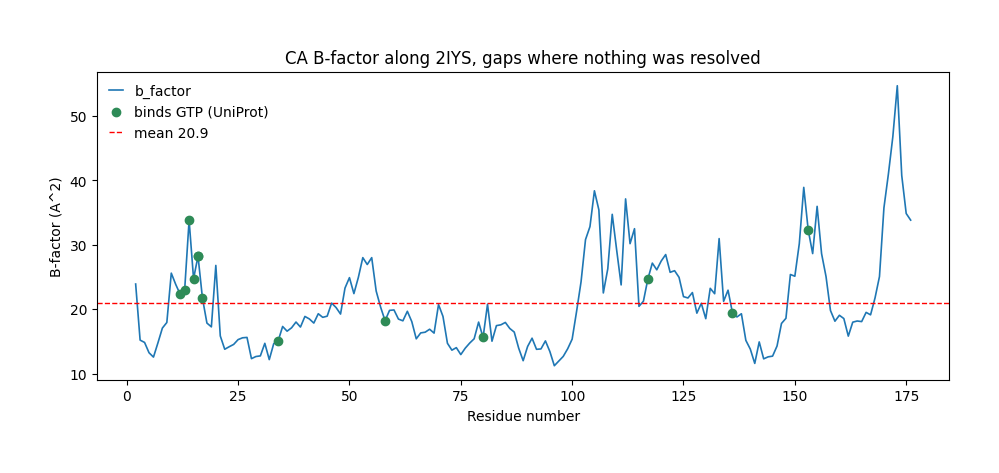

In [26]:
atoms_chain_a = atoms_df[
    (atoms_df["chain_id"] == "A") &
    (atoms_df["atom_name"] == "CA")
].drop_duplicates(subset="residue_number")

bfactors = bfactor_profile(atoms_chain_a)
print(f"Residue range: {bfactors.index.min()} to {bfactors.index.max()}")
print(f"Present: {bfactors.notna().sum()}   Missing: {bfactors.isna().sum()}")
print(f"\nB-factor: mean {bfactors.mean():.1f}, min {bfactors.min():.1f}, "
      f"max {bfactors.max():.1f} A^2")
print(f"GTP-binding residues: mean {bfactors[gtp].mean():.1f} A^2, and "
      f"{(bfactors[gtp] < bfactors.mean()).sum()} of {len(gtp)} below the protein's mean")

ax = bfactors.plot(figsize=(11, 4), lw=1.2,
                   title=f"CA B-factor along {pdb_id}, gaps where nothing was resolved")
ax.scatter(gtp, bfactors[gtp], color="seagreen", zorder=3, label="binds GTP (UniProt)")
ax.set_ylabel("B-factor (A^2)")
ax.axhline(bfactors.mean(), color="red", ls="--", lw=1, label=f"mean {bfactors.mean():.1f}")
ax.legend()
plt.show()

**Comparison with my prediction**

The B-factor analysis of 2IYS shows a mean value of 20.9 Å², with values ranging from 11.2 to 54.7 Å². Elevated B-factors are observed around residues 100–120, 150–155, and particularly near the C-terminus (170–176).

This partially supports my prediction that terminal regions and potentially flexible loops would show higher B-factors. The annotated binding-site residues have a slightly higher mean B-factor (23.6 Å²) than the protein overall, suggesting some local structural disorder. However, the elevated regions need to be examined in the 3D structure before attributing them to specific loops or conformational movements.

In [28]:
show_structure("2IYS", color="b-factor", ligand="GDP").show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

---

## 4. Multiple sequence alignment, and conservation on the structure (required)

Build an alignment, then **put its result back onto your 3D structure**.

**Step 1: build the alignment**, the way the guide does. Take your protein's UniProt
sequence from section 1, find its relatives in Swiss-Prot (`hmmer_search`), align the full sequences (`align`), and
keep one representative per 95% group (`drop_redundant`). Report how many relatives came
back and how many are left. Read their names: one family, or a superfamily, the way FtsZ
reaches tubulin? Keep distant relatives, and say what they are.

**Step 2: predict first, then compute.** Where do you *expect* conservation to cluster: an
active site, a ligand pocket, an interface? Write it down before computing anything.

> **My prediction:** I expect residues involved in substrate binding and catalysis to be more strongly conserved than residues on the protein surface. In particular, I predict higher conservation around the shikimate-binding pocket, including some of the contact residues identified in Section 2, because these positions are important for the enzyme's function.

Then compute conservation (`conservation`) and move it onto your structure's own residue
numbers with the mapping from section 1. Call the most conserved 10% of your
modelled residues conserved, and report the cutoff value that gives.

**Step 3: put it on the structure.** Required: render the conserved residues with your
ligand in the same view, as the guide does for 1FSZ and its GDP, and add that view to your
section 2 figures.

**Step 4: interpret, against a baseline.** Report three numbers: how many of your
ligand's contact residues (from the Character Sheet) are conserved, how many chance would
give (10% of them), and the ratio. On 1FSZ: 8 of 17 against about 2. Matching chance is a
real finding too. Look at the alignment itself (`show_alignment`) as well. For each contact that misses the cutoff, is it a *gap* or a *different
amino acid*? Does conservation coincide with the rigid regions from section 3?

**Judge your own alignment.** Few relatives (under about ten after grouping) make almost
every column look conserved. If that is your case, say so, and weigh your numbers
accordingly.

**Timing:** seconds for the search on EBI's servers, a few more to download and align.

In [29]:
HMMER = "https://www.ebi.ac.uk/Tools/hmmer/api/v1"


def hmmer_search(sequence: str, database: str = "swissprot",
                 timeout: float = 600.0) -> dict[str, str]:
    """Search with phmmer at EBI: the full sequence of every significant hit, best first.

    Returns {UniProt entry name: full-length sequence}. Full length, not only the stretch
    that matched, because the alignment is built from whole proteins.
    """
    submitted = requests.post(f"{HMMER}/search/phmmer",
                              json={"input": f">query\n{sequence}", "database": database})
    submitted.raise_for_status()
    job = submitted.json()["id"]
    deadline = time.time() + timeout

    # 1. Ask until the search is done. A busy server can briefly answer with an error
    #    page instead of a status; that just means "ask again".
    status = None
    while status != "SUCCESS":
        if status == "FAILURE" or time.time() > deadline:
            raise RuntimeError(f"phmmer job {job} did not finish (last status: {status})")
        time.sleep(2)
        answer = requests.get(f"{HMMER}/result/{job}", params={"page_size": 1})
        status = answer.json().get("status") if answer.ok else None
    if answer.json()["result"]["stats"]["nincluded"] == 0:
        return {}

    # 2. The file of full-length hits is made on request: ask for it, then fetch it
    #    until it exists.
    requests.post(f"{HMMER}/download/{job}/fullfasta")
    while not (download := requests.get(f"{HMMER}/download/{job}/fullfasta")).ok:
        if time.time() > deadline:
            raise RuntimeError(f"no sequence file for phmmer job {job}")
        time.sleep(2)
    fasta = gzip.decompress(download.content).decode()
    return {rec.id: str(rec.seq) for rec in SeqIO.parse(io.StringIO(fasta), "fasta")}


def align(sequences: dict[str, str]) -> dict[str, str]:
    """A multiple sequence alignment of `sequences`, made locally with FAMSA.

    FAMSA returns the rows in its own order; they are put back in the order given.
    """
    msa = Aligner(guide_tree="upgma").align(
        [Sequence(name.encode(), seq.encode()) for name, seq in sequences.items()])
    rows = {row.id.decode(): row.sequence.decode() for row in msa}
    return {name: rows[name] for name in sequences}


def drop_redundant(aligned: dict[str, str], anchor: str,
                   max_identity: float = 0.95) -> dict[str, str]:
    """`anchor` first, then one representative per group of near-identical sequences.

    The others are taken in the order given (best hit first) and each is kept only if it
    is less than `max_identity` identical to every sequence kept so far, so a group is
    represented by its best match. Identity is counted over the anchor's residues, at the
    positions where both sequences have one.
    """
    names = [anchor, *(name for name in aligned if name != anchor)]
    columns = [col for col, char in enumerate(aligned[anchor]) if char != "-"]
    rows = np.array([[aligned[name][col] for col in columns] for name in names])
    has_residue = rows != "-"
    kept = [0]
    for i in range(1, len(rows)):
        both = has_residue[kept] & has_residue[i]
        same = (rows[kept] == rows[i]) & both
        identity = same.sum(axis=1) / np.maximum(both.sum(axis=1), 1)
        if identity.max() < max_identity:
            kept.append(i)
    return {names[i]: aligned[names[i]] for i in kept}


def conservation(aligned: dict[str, str], anchor: str) -> pd.Series:
    """Per residue of the anchor: the fraction of sequences carrying the same amino acid.

    Indexed by the anchor's own numbering (1 = its first residue), which for a UniProt
    sequence is UniProt numbering. A gap counts as not keeping the residue.
    """
    columns = [col for col, char in enumerate(aligned[anchor]) if char != "-"]
    rows = np.array([[row[col] for col in columns] for row in aligned.values()])
    anchor_row = np.array([aligned[anchor][col] for col in columns])
    kept = (rows == anchor_row).mean(axis=0)
    return pd.Series(kept, index=range(1, len(columns) + 1), name="conservation")


def show_alignment(aligned: dict[str, str], n_sequences: int = 10) -> None:
    """Draw the first `n_sequences` of the alignment over its whole length, letters and all.

    Columns where none of them has a residue belong to other sequences' insertions and are
    left out. The bar underneath is the consensus of the rows drawn.
    """
    shown = dict(list(aligned.items())[:n_sequences])
    rows = np.array([list(seq) for seq in shown.values()])
    rows = rows[:, (rows != "-").any(axis=0)]
    records = [SeqRecord(Seq("".join(row)), id=name, description="")
               for name, row in zip(shown, rows)]
    MsaViz(MultipleSeqAlignment(records), color_scheme="Clustal", wrap_length=80,
           show_grid=True, show_consensus=True).plotfig(dpi=72)

In [30]:
relatives = hmmer_search(query)
aligned = drop_redundant(align({accession: query, **relatives}), anchor=accession)

print(f"2IYS chain A is UniProt {accession}, {len(query)} residues; the structure holds "
      f"UniProt {to_structure.index.min()}-{to_structure.index.max()}")
print(f"Swiss-Prot relatives, full length: {len(relatives)}")
print(f"Alignment: {len(aligned[accession])} columns")
print(f"After grouping at 95%: {len(aligned) - 1} relatives, plus {accession} itself")

2IYS chain A is UniProt P9WPY3, 176 residues; the structure holds UniProt 1-176
Swiss-Prot relatives, full length: 385
Alignment: 2400 columns
After grouping at 95%: 278 relatives, plus P9WPY3 itself


Who came back?

The HMMER search identifies proteins related to shikimate kinase (2IYS) in the Swiss-Prot database. Their UniProt entry names provide information about protein identity and organism. Examining these names helps determine whether the alignment mainly contains shikimate kinases from different species or also includes more distantly related proteins.

In [31]:
mnemonic = pd.Series([
    name.split("_")[0].rstrip("0123456789")
    for name in list(aligned)[1:]
])

mnemonic.value_counts().head(12)

,count
AROK,210
ARO,42
AROL,13
SK,6
AROKB,2
THNS,2
KAD,2
KCY,1


The HMMER search identified 385 Swiss-Prot relatives of shikimate kinase (2IYS). After removing sequences with at least 95% identity, 278 relatives remained, together with the reference protein P9WPY3. The resulting multiple sequence alignment contains 2,400 columns, including insertions and gaps.

The number of retained sequences provides a substantial dataset for conservation analysis, although the alignment quality and evolutionary diversity still need to be considered.

### **Conservation, residue by residue**

Conservation scores were calculated from the multiple sequence alignment of 279 sequences, including the reference protein P9WPY3. The scores are mapped from UniProt numbering to the residue numbering of the crystal structure 2IYS.

The top 10% most conserved residues are selected to identify positions that may be important for protein structure or function. These positions will then be compared with the SKM-binding pocket to investigate whether ligand-contact residues are particularly conserved.

In [33]:
by_uniprot = conservation(aligned, accession)
in_structure = by_uniprot[by_uniprot.index.isin(to_structure.index)]
in_structure.index = to_structure[in_structure.index].to_numpy()  # UniProt -> 2IYS

# Only residues the crystal modelled can be drawn, so the cutoff is taken over those.
modelled = in_structure[in_structure.index.isin(atoms_chain_a["residue_number"])]

CONSERVED_SHARE = 0.10  # the most conserved tenth of the modelled residues
cutoff = modelled.quantile(1 - CONSERVED_SHARE)
conserved = modelled[modelled >= cutoff]

print(f"{len(modelled)} modelled residues, {len(aligned)} sequences in the alignment")
print(f"Cutoff: kept by at least {cutoff:.0%} of the sequences -> "
      f"{len(conserved)} conserved residues")

175 modelled residues, 279 sequences in the alignment
Cutoff: kept by at least 88% of the sequences -> 18 conserved residues


In [34]:
# The 7 SKM contacts identified earlier, compared against chance.
baseline = len(conserved) / len(modelled)
expected = baseline * len(contact_resids)
observed = len(set(contact_resids) & set(conserved.index))

print(f"Conserved SKM contacts: {observed} of {len(contact_resids)}; "
      f"by chance about {expected:.1f} ({observed / expected:.1f}x)")

residue = atoms_chain_a.drop_duplicates("residue_number").set_index("residue_number")["residue_name"]

print("\nConserved residues:")
print(", ".join(f"{residue[r]}{r}" for r in conserved.index))

Conserved SKM contacts: 6 of 7; by chance about 0.7 (8.3x)

Conserved residues:
GLY9, GLY12, GLY14, LYS15, GLY19, ASP32, ASP34, GLY53, PHE57, ARG58, GLU61, GLY79, GLY80, GLY81, ARG117, PRO118, ARG136, TYR140


**Inspecting the alignment**

The multiple sequence alignment contains 279 sequences and 2,400 columns. To inspect the alignment visually, the first ten sequences and the last ten sequences are displayed separately.

Particular attention is given to the SKM-binding residues identified in 2IYS, to examine whether these positions are conserved across related proteins or contain substitutions and gaps.

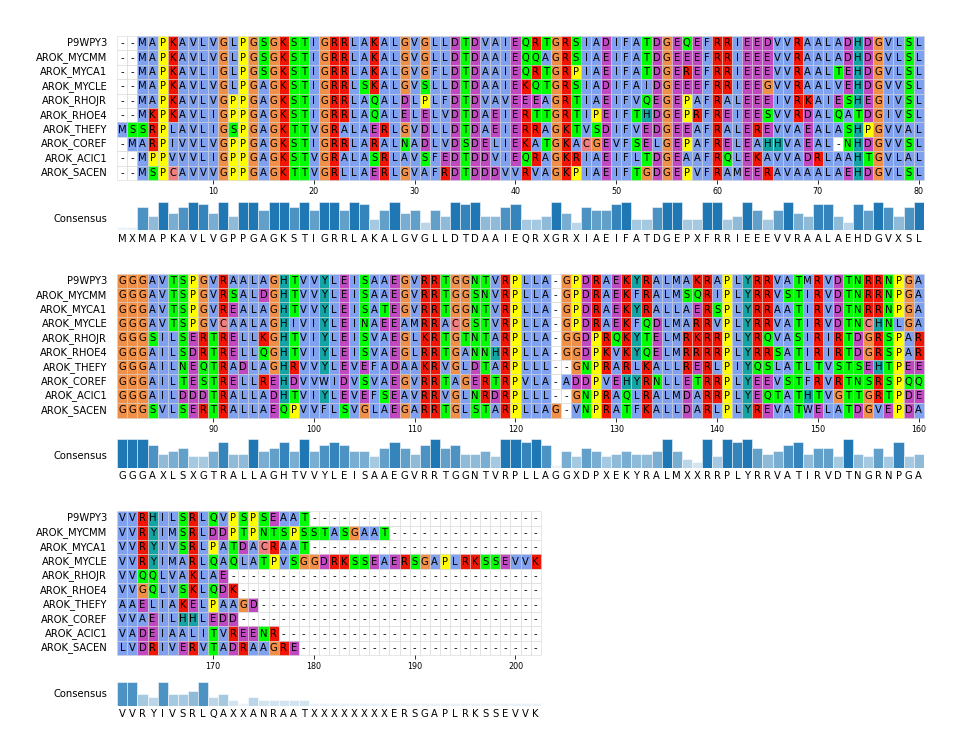

In [35]:
show_alignment(aligned)

In [37]:
show_structure("2IYS", highlight=conserved.index.tolist(), ligand="GDP").show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Interpretation: Sequence conservation and the SKM-binding pocket

The alignment contained 279 sequences after 95% identity filtering. Using a conservation cutoff of 87.9%, **6 of the 7 SKM-contact residues were classified as conserved**, compared with approximately 0.7 expected by chance (8.3-fold enrichment).

Particularly high conservation was observed for ASP34, ARG58, GLY79–GLY81, and ARG136 (97.5–99.3%), suggesting that these residues are important for substrate binding and protein function.

ILE45 was the only contact below the cutoff (74.6%). However, most remaining sequences contained valine instead of isoleucine, indicating a conservative substitution rather than a gap.

Overall, the results support the prediction that the SKM-binding pocket is strongly evolutionarily conserved, highlighting its likely functional importance.

---

## Before you submit

- [ ] Character Sheet filled in (PDB ID, name, organism, why, open question)
- [ ] Both **predictions written before** their analyses (the B-factor prediction in
      section 3, the conservation prediction in section 4)
- [ ] **Conserved residues rendered on your structure**, added to your section 2 figures
- [ ] The **three conservation numbers**: observed, expected by chance, ratio
- [ ] Every section has a **written interpretation**, not just output
- [ ] Domain boundaries and any external claims are **cited**
- [ ] Anything that didn't work is **described honestly** rather than deleted — a
      documented dead end earns marks, a silently missing section does not